# Bearing Failure Detection from Vibration Data

Unsupervised anomaly detection on the NASA/IMS bearing run-to-failure dataset. Four bearings ran on the same shaft for ~7 days until an outer-race failure occurred in Bearing 1. The dataset contains 984 files, each with 20,480 samples and each file is recorded in 10-minute intervals with a 20 kHz sampling rate across all four channels.

**Problem.** With only one failure event across four bearings and no labels, supervised learning is not available. The detector needs to learn what healthy operation looks like and flag signals that deviate from it early enough to schedule maintenance and prevent significant downtime.

**Approach.** First, validate the data and collapse each snapshot down to four time-domain features per bearing. Fit a PCA model on healthy behaviour using the first 500 files only, then score every file based on how poorly its features reconstruct from that model.

**Result.** Bearing 1 was flagged 74 hours (3.1 days) before failure, with zero false alarms across 1,554 control-bearing observations, and 30 hours before any other bearing was flagged. The alarm remained continuously active until the end of the test.

Checks 1–5 validate the data before any modelling. Steps 6–11 build and evaluate the detector. 

In [1]:
import os
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq
from sklearn.decomposition import PCA

path = '/kaggle/input/datasets/vinayak123tyagi/bearing-dataset/2nd_test/2nd_test'
FS = 20000 # sampling rate, from the README


files = sorted(os.listdir(path))
print(len(files), 'files')      

984 files


In [2]:
print(files[:5])

df = pd.read_csv(os.path.join(path, files[0]), sep='\t', header=None)
print(df.shape)
df.head()

['2004.02.12.10.32.39', '2004.02.12.10.42.39', '2004.02.12.10.52.39', '2004.02.12.11.02.39', '2004.02.12.11.12.39']
(20480, 4)


,0,1,2,3
0,-0.049,-0.071,-0.132,-0.010
1,-0.042,-0.073,-0.007,-0.105
2,0.015,0.000,0.007,0.000
3,-0.051,0.020,-0.002,0.100
4,-0.107,0.010,0.127,0.054


### Check 1 — File shape and missing value check

Every file needs the same shape and no missing values before any processing. A
single odd-shaped or corrupt file will break the feature-extraction loop, or worse,
pass through silently and corrupt the features.

**Found.** All 984 files are (20480, 4) — 20,480 samples x 4 bearings — and none contain missing values.

**Verdict.** Safe to continue; no format issues should arise later.

In [3]:
shapes = set()
bad = []
for f in files:
    d = pd.read_csv(os.path.join(path, f), sep='\t', header=None)
    shapes.add(d.shape)
    if d.isna().any().any():
        bad.append(f)
print(shapes)   
print(f'{len(bad)} files with missing values!')     

{(20480, 4)}
0 files with missing values!


### Check 2 — Are the timestamps correct?

All files are named Y.M.D.H.M.S. Because those fields are fixed-width and
zero-padded, sorting file names alphabetically puts them in time order. Checking
that the order is monotonic and that the spacing is even, so file number can be used
directly as a time axis.

**Found.** Order is monotonic, and all 981 gaps are exactly 10 minutes. The README
warned of overnight pauses in other test sets, but none were found here, so
recording is continuous.

**Verdict.** A perfectly regular time series. File number is directly proportional
to real time, so no gap-filling or resampling is needed and rolling medians can be
applied correctly.

In [4]:
ts = pd.to_datetime(pd.Series(files), format='%Y.%m.%d.%H.%M.%S')
print(ts.is_monotonic_increasing)   # True
gaps = ts.diff().dt.total_seconds() / 60
print(gaps.value_counts().head())   # 10.0 - perfectly regular series.                                  

True
10.0    983
Name: count, dtype: int64


### Check 3 — Are any channels dead or clipped?

Two opposite faults. A 'dead' channel reads a near-constant value and it looks like a perfectly healthy bearing. A
'clipped' channel is the opposite: vibration exceeded the sensor's range so the
peaks were chopped flat, which destroys peak and kurtosis values while still
looking plausible. I checked the first and last files with `.describe()` to see
whether either had occurred.

**Found.** Healthy at the start — std 0.05-0.11 across all four bearings, max ~1.0
with no clipping, and a small offset of ~-0.01 from zero (electrical bias,
consistent on all four channels). The final file had std ~0.001 on all four channels, the sensors were off, not a failed bearing.

**Verdict.** All four sensors worked correctly for the whole test apart from the final recordings.

**Decision.** Run checks on the last files to detect which sensors are dead.

In [5]:
d0 = pd.read_csv(os.path.join(path, files[0]), sep='\t', header=None)
print(d0.describe())       

d_last = pd.read_csv(os.path.join(path, files[-1]), sep='\t', header=None)
print(d_last.describe())   

                  0             1             2             3
count  20480.000000  20480.000000  20480.000000  20480.000000
mean      -0.010196     -0.012695     -0.014541     -0.010026
std        0.073477      0.090056      0.108436      0.053168
min       -0.386000     -0.513000     -0.911000     -0.264000
25%       -0.059000     -0.073000     -0.081000     -0.046000
50%       -0.010000     -0.015000     -0.015000     -0.010000
75%        0.037000      0.046000      0.051000      0.027000
max        0.454000      0.464000      1.023000      0.193000
                  0             1             2             3
count  20480.000000  20480.000000  20480.000000  20480.000000
mean      -0.001162     -0.000701     -0.000664     -0.001695
std        0.001000      0.001021      0.000996      0.001280
min       -0.005000     -0.002000     -0.005000     -0.005000
25%       -0.002000     -0.002000     -0.002000     -0.002000
50%       -0.002000      0.000000      0.000000     -0.002000
75%     

Scanning the std of the last 15 files to find where the signal stops.

In [6]:
for f in files[-15:]:
    d = pd.read_csv(os.path.join(path, f), sep='\t', header=None )
    print(f, d.std().round(4).values)

2004.02.19.04.02.39 [0.3257 0.1484 0.1561 0.1187]
2004.02.19.04.12.39 [0.3531 0.1842 0.1838 0.1341]
2004.02.19.04.22.39 [0.4297 0.191  0.1874 0.1424]
2004.02.19.04.32.39 [0.4156 0.1628 0.1554 0.1278]
2004.02.19.04.42.39 [0.3717 0.1366 0.1207 0.1174]
2004.02.19.04.52.39 [0.4477 0.1909 0.1652 0.1299]
2004.02.19.05.02.39 [0.6721 0.1911 0.1762 0.1246]
2004.02.19.05.12.39 [0.5309 0.1711 0.1604 0.1469]
2004.02.19.05.22.39 [0.4459 0.1732 0.1495 0.1464]
2004.02.19.05.32.39 [0.387  0.1767 0.1394 0.1434]
2004.02.19.05.42.39 [0.725  0.2183 0.1706 0.1483]
2004.02.19.05.52.39 [0.462  0.1708 0.1779 0.1166]
2004.02.19.06.02.39 [0.4838 0.1936 0.1874 0.1305]
2004.02.19.06.12.39 [0.001  0.0015 0.0015 0.0012]
2004.02.19.06.22.39 [0.001  0.001  0.001  0.0013]


**Found.** Std drops to approximately 0.001 - sensors were off before the test ended.

**Decision.** Drop the last two files.

In [7]:
files = files[:-2]
print(len(files), 'files retained')

982 files retained


### Check 4 — Is this real machine vibration?

I used an FFT to split the signal into the frequencies it is made of. From the
README, the shaft rotated at a constant 2000 RPM = 33.3 Hz, so I expected a peak
there.

**Found.** No significant 33.3 Hz peak. Instead, evenly spaced peaks roughly 7 Hz
apart, consistent across all four channels — so the source is shaking the whole rig
rather than originating at any one bearing.

**Verdict.** Real machine vibration confirmed. Exact shaft speed not confirmed, as
it could not be verified from the data.

**Decision.** Use statistical features such as RMS and kurtosis rather than bearing
fault frequencies, since those depend on knowing the shaft speed.

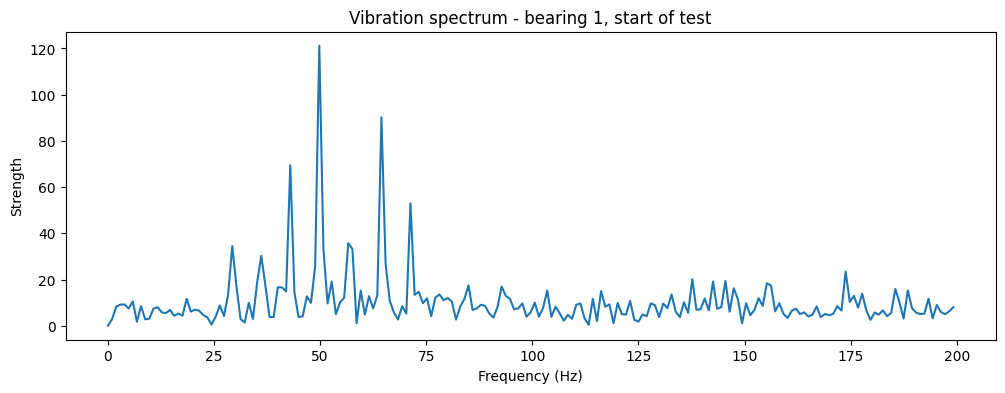

b1 [43.  49.8 56.6 64.5 71.3]
b2 [43.  49.8 56.6 64.5 71.3]
b3 [43.  49.8 56.6 64.5 71.3]
b4 [43.  49.8 56.6 64.5 71.3]


In [8]:
x = d0[0].values                
x = x - x.mean()                
spec = np.abs(rfft(x))            
fr = rfftfreq(len(x), 1/FS)     

plt.figure(figsize=(12,4))
plt.plot(fr[fr<200], spec[fr<200])   
plt.xlabel('Frequency (Hz)')
plt.ylabel('Strength')
plt.title('Vibration spectrum - bearing 1, start of test')
plt.show()

#Top 5 peaks on all 4 channels 
low = fr < 200
for ch in range(4):
    v = d0[ch].values
    v = v - v.mean()
    Xc = np.abs(rfft(v))
    print('b' + str(ch+1), np.sort(fr[low][np.argsort(Xc[low])[-5:]].round(1))) 

### Check 5 — Does degradation show up?

Each file's 20,480 samples were collapsed into one RMS value per bearing (a measure
of typical vibration magnitude), so all 982 files could be compared on one plot. If
the data is useful, the failing bearing should get louder over the week while the
others stay flat.

**Found.** Bearing 1 rose 536% (6.4x) from the first 100 files to the last 10,
against 53-140% for the three bearings that didn't fail. b1 also starts as the
second quietest of the four and ends as by far the loudest. The rise isn't smooth — b1
jumps at ~file 700, dips back to near baseline by ~790, then runs away after ~950.
The dip is a known effect where the initial damage temporarily wears smooth; the
bearing hasn't recovered.

**Verdict.** Strong degradation signal, localised to bearing 1 — the bearing the
README identifies as failed. Safe to build on.

**Decision.** RMS works as a feature but not as a health index, since the dip makes
it non-monotonic. Adding kurtosis next, as it reacts earlier to the sharp impacts
that bearing damage produces.

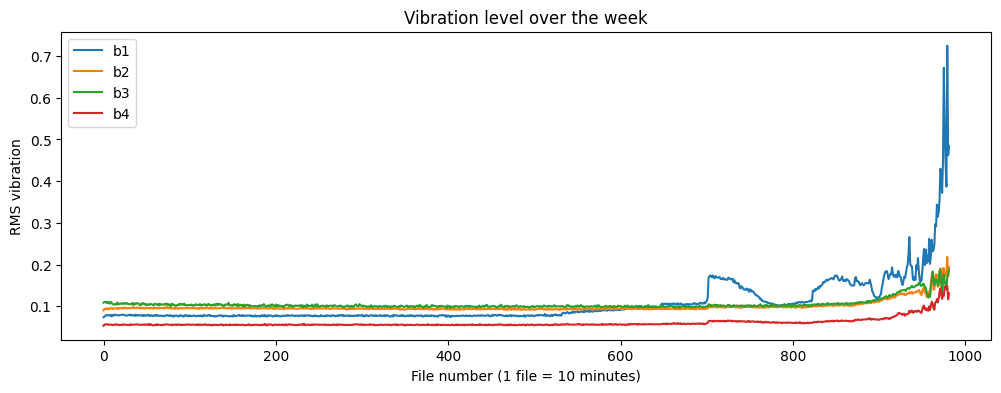

b1 536%
b2 87%
b3 53%
b4 140%


,b1,b2,b3,b4
0,0.073475,0.090053,0.108434,0.053166
1,0.075338,0.093384,0.109790,0.055973
2,0.076189,0.093703,0.109849,0.056037
3,0.078691,0.092916,0.110622,0.056684
4,0.078437,0.095335,0.107499,0.056777


In [9]:
rows = []
for f in files:
    a = pd.read_csv(os.path.join(path, f), sep='\t', header=None).values
    a = a - a.mean(axis=0)                      # remove offset
    rows.append(np.sqrt((a**2).mean(axis=0)))   # RMS per bearing

rms = pd.DataFrame(rows, columns=['b1','b2','b3','b4'])

rms.plot(figsize=(12,4))
plt.xlabel('File number (1 file = 10 minutes)')
plt.ylabel('RMS vibration')
plt.title('Vibration level over the week')
plt.show()

for b in ['b1','b2','b3','b4']:
    change = ((rms[b][-10:].mean() - rms[b][:100].mean()) / rms[b][:100].mean()) * 100
    print(b, str(round(change)) + '%')

rms.head()

### Step 6 — Building the features

Each file's 20,480 samples were collapsed into four statistical measures per
bearing: RMS, kurtosis, peak and crest factor. RMS and peak capture overall
severity, which rises late, closer to failure; kurtosis and crest capture the
extreme outlier values produced by early impacts. This combination covers the whole
failure timeline rather than only one end of it.

**Result.** A dataframe X of 982 x 16 (4 features x 4 bearings), each row a single
snapshot, with 20,480 samples collapsed to four numbers per bearing. This replaces the raw data and becomes the source
for all following steps.

**Next.** Standardise each feature, as they currently sit on very different scales.
Principal component analysis (PCA) re-describes the data using its axes of greatest
variation, so an unscaled feature would dominate those axes purely because of its
units. PCA is then fitted separately for each bearing, using that bearing's healthy
period only, so "normal" is defined without the failure in it.

In [10]:
features = []

for f in files:
    a = pd.read_csv(os.path.join(path,f), sep='\t', header=None).values
    a = a - a.mean(axis=0)
    
    rms_ = np.sqrt((a**2).mean(axis=0))
    kurt = (a**4).mean(axis=0) / (a**2).mean(axis=0)**2
    peak = np.abs(a).max(axis=0)
    crest = peak / rms_
    features.append(np.concatenate([rms_, kurt, peak, crest]))
    
cols = [n + '_b' + str(i) for n in ['rms', 'kurt', 'peak', 'crest'] for i in range(1,5)]
X = pd.DataFrame(features, columns=cols)
print(X.shape)
X.head()

(982, 16)


,rms_b1,rms_b2,rms_b3,rms_b4,kurt_b1,kurt_b2,kurt_b3,kurt_b4,peak_b1,peak_b2,peak_b3,peak_b4,crest_b1,crest_b2,crest_b3,crest_b4
0,0.073475,0.090053,0.108434,0.053166,3.628763,3.506801,6.213075,3.065959,0.464196,0.500305,1.037541,0.253974,6.317747,5.555644,9.568453,4.776966
1,0.075338,0.093384,0.109790,0.055973,3.648291,3.253014,4.395250,3.107539,0.385415,0.478439,0.754461,0.252784,5.115803,5.123364,6.871869,4.516162
2,0.076189,0.093703,0.109849,0.056037,3.513475,3.310789,5.639948,3.257236,0.505484,0.501305,0.934595,0.357485,6.634580,5.349956,8.507966,6.379460
3,0.078691,0.092916,0.110622,0.056684,4.157953,3.235341,5.682779,3.806190,0.610277,0.571393,1.019148,0.521259,7.755379,6.149544,9.212907,9.195858
4,0.078437,0.095335,0.107499,0.056777,3.603177,3.226309,4.578395,3.138954,0.393404,0.484441,0.769842,0.246703,5.015510,5.081448,7.161359,4.345141


### Step 7 — Standardising the data

Each feature is converted to a standardised value describing how many standard
deviations it sits from the healthy average. The mean and standard deviation are
taken from files 0-499 only, the healthy region identified from the RMS
plot in Check 5.

Using statistics from the full dataset would include the failure in the definition
of "normal": the mean would be pulled upward and the standard deviation inflated,
so degraded readings would appear only slightly abnormal. Restricting the fit to
healthy files keeps the reference clean.

**Result.** Healthy rows are centred at 0 with standard deviation 1; later rows sit
far above that, which is the signal being looked for.

**Next.** Fit PCA on the healthy rows and project the full dataset onto it.

In [11]:
healthy = X.iloc[:500]
X_scaled = (X - healthy.mean()) / healthy.std()
X_scaled.head()

,rms_b1,rms_b2,rms_b3,rms_b4,kurt_b1,kurt_b2,kurt_b3,kurt_b4,peak_b1,peak_b2,peak_b3,peak_b4,crest_b1,crest_b2,crest_b3,crest_b4
0,-3.480635,-3.209041,2.555100,-3.303676,2.198450,4.804269,3.587712,-1.004116,1.536731,0.544559,2.134075,-0.207649,2.181536,0.993719,1.635536,0.140278
1,-1.728920,-0.651131,3.043979,0.928683,2.403821,1.006436,-0.320664,-0.377348,-0.452561,0.139665,-0.159007,-0.246639,-0.219025,0.225372,-0.646579,-0.344461
2,-0.928675,-0.406285,3.065501,1.024912,0.986033,1.871026,2.355473,1.879141,2.579291,0.563067,1.300168,3.182896,2.814326,0.628123,0.738047,3.118734
3,1.423119,-1.010193,3.343883,2.000843,7.763669,0.741965,2.447561,10.153903,5.225401,1.860896,1.985083,8.547361,5.052821,2.049335,1.334638,8.353400
4,1.184987,0.847715,2.218372,2.140364,1.929378,0.606805,0.073103,0.096185,-0.250835,0.250803,-0.034416,-0.445827,-0.419334,0.150870,-0.401584,-0.662328


### Step 8 — Creating the PCA function

The four features are not independent. Crest factor is directly related to peak
and RMS, defined as peak/RMS. Additionally, on a healthy bearing you would
expect RMS and peak to rise together as overall amplitude increases. The four
numbers therefore follow a smaller number of patterns which describe the variation.

PCA finds new axes, called principal components, which are linear combinations of
the original four features. These components describe the main patterns of variation
within the data: PC1 describes the largest pattern, PC2 the second largest, and so on.

The PCA was fitted using only healthy files (0-499) and then used to transform all
982 rows. The principal components are therefore defined by what a healthy bearing
looks like. Fitting on the whole dataset would allow the failure to influence the
definition of "normal", potentially making anomalies harder to identify.

**Result.** Component loadings show PC1 is mainly associated with peak, crest factor
and kurtosis. PC2 is mainly associated with RMS, representing
amplitude as a second, separate pattern of variation.

Explained variance ratios: [0.632, 0.243, 0.125, 0.000]

PC4 captures essentially no variance: of the four features, only three carry
independent information, due to the mathematical relationship between crest factor,
peak and RMS.

**Decision.** PC1 and PC2 capture approximately 88% of the healthy variation and are
retained; PC3 and PC4 are discarded. Variation that cannot be represented by the
retained components then contributes to the reconstruction error, providing evidence
that an observation does not fit the healthy model.

In [12]:
def apply_PCA(X, bearing, n_healthy=500):
    
    cols = [ c for c in X.columns if c.endswith('_b' + str(bearing)) ]
    Xb = X[cols]

    pca = PCA()
    pca.fit(Xb.iloc[:n_healthy]) # learn on healthy
    scores = pca.transform(Xb)
    
    col_name = [f"PC{i}" for i in range(1,len(cols) + 1)]
    X_PCA = pd.DataFrame(scores, columns=col_name)
    return X_PCA, pca

X_pca_b1, pca_b1 = apply_PCA(X_scaled, 1)
print(pca_b1.explained_variance_ratio_.round(3))

pd.DataFrame(pca_b1.components_.round(2), columns = [c for c in X_scaled.columns if c.endswith('_b1')], index = ['PC1', 'PC2', 'PC3', 'PC4'])

[0.632 0.243 0.125 0.   ]


,rms_b1,kurt_b1,peak_b1,crest_b1
PC1,0.22,0.49,0.60,0.59
PC2,0.93,0.15,-0.17,-0.30
PC3,-0.29,0.86,-0.32,-0.28
PC4,-0.10,-0.00,0.71,-0.70


### Step 9 - Anomaly detection by reconstruction error

Each file is projected onto the two retained components and then reconstructed back into the origional four features. The result is the closest description of that file achievable using only the patterns present in healthy operation

Because only two of the four components is retained, the reconstruction is never exact - the variation held in PC3 and PC4 is discarded, so every file carries some residual. On healthy files this residual is small, since healthy behaviour is almost entirely captured with PC1 and PC2. As a fault develops, feature combinations appear that cannot be produced by the two components retained.

The anomaly score is the Euclidean distance between the observed features and their reconstruction:

    score = sqrt( sum(observed - reconstructed)^2 )

Squarring collects errors in both directions and the sum collapses each features error into the total error per file.

The score therefore measures how far a reading departs from the relationships between four features in a healthy operating range. Detection requires defining the residual range considered normal; anything beyond is flagged.

**Result.** Bearing 1 seperates clearly from the other three from roughly file 530 onward, rising by two orders of magnitude by the end of the test. Bearings 2-4 remain within the healthy band until later. The seperation confirms that the fault produced feature combinations outside of those observed during the healthy period.

The raw score is too noisy to determine a threshold which will be addressed next

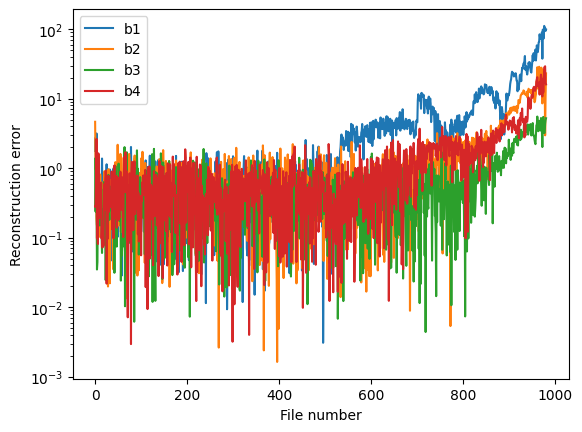

In [13]:
def anomaly_score(X, bearing, n_healthy=500, k=2):
    cols = [c for c in X.columns if c.endswith('_b'+ str(bearing))]
    Xb = X[cols].values
    pca = PCA(n_components = k)
    pca.fit(Xb[:n_healthy])
    recon = pca.inverse_transform(pca.transform(Xb))
    return np.sqrt(((Xb-recon)**2).sum(axis=1))
for b in range(1,5):
    plt.plot(anomaly_score(X_scaled, b), label = 'b' + str(b))
plt.legend(); plt.xlabel('File number'); plt.ylabel('Reconstruction error')
plt.yscale('log'); plt.show()

### Step 10 - Smoothing, threshold and persistance

Since the raw score is too noisy to threshold: healthy readings reach up to an approximate recontruction error 5. Three adjustments are made to produce an alarm.

**Smoothing** - 10-file rolling median so a single spike is ignored. Backward-looking only, so the detector stays usable in real time.
**Threshold** - 1.5x the highest smoothed healthy value on any bearings. Files 0-19 are excluded, as the rolling window is not yet full here and the unsmoothed noise would then inflate the threshold.
**Persistance** - three consecutive files above the line, timestamped at the first. Faults stay above the threshold while noise will fall back.

No parameter uses data from after file 500, so the detector could have been configured before the fault began.

**Result.** Threshold 1.83, Bearing 1 alarms at file 538, the others not until 717, 825 and 912.

threshold = 1.83
b1 538
b2 825
b3 912
b4 717


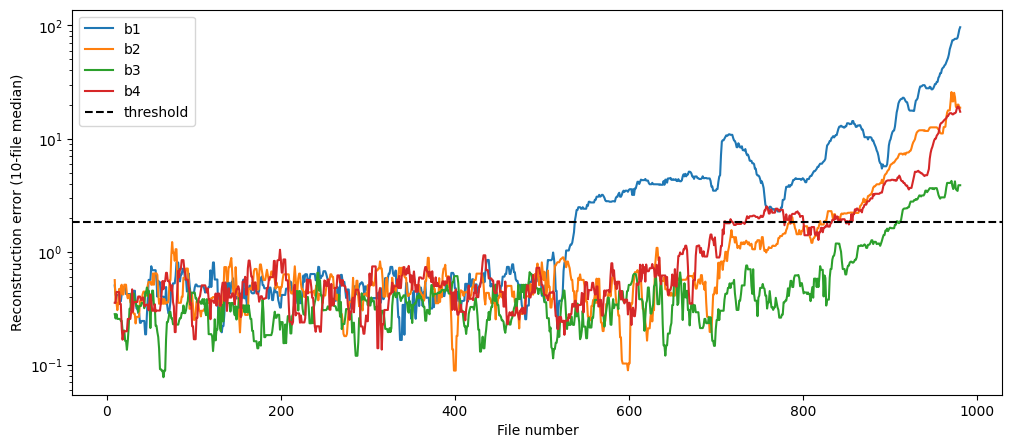

In [14]:
S = pd.DataFrame({f'b{b}':anomaly_score(X_scaled, b) for b in range(1,5)})
Ssm = S.rolling(10).median()          
base = Ssm.iloc[20:500]               # skip the startup transient
thr = base.max().max() * 1.5
print(f"threshold = {thr:.2f}")


def first_alarm(s, thr, n=3):
    over = (s > thr).values
    for i in range(len(over) - n + 1): #Last position where 3 files exist is 979; need range(980)
        if over[i:i+n].all():
            return i
    return None
for b in Ssm.columns:
    print(b, first_alarm(Ssm[b].fillna(0), thr))

Ssm.plot(figsize=(12,5), logy=True)
plt.axhline(thr, color='k', ls='--', label='threshold')
plt.xlabel('File number'); plt.ylabel('Reconstruction error (10-file median)')
plt.legend(); plt.savefig('detection.png', dpi=150, bbox_inches='tight'); plt.show()

# Step 11 - Evaluation

Lead time is measured from the first alarm to end of test at 10 minutes per file. False alarms are counted on the three bearings that did not fail, over the window ending at the first alarm before b1's fault transmits through the rest of the housing, since alarms after that point reflect genuine vibration on those sensors rather than detector error.

In [15]:
FAIL = 982

alarms = {b: first_alarm(Ssm[b].fillna(0), thr) for b in Ssm.columns}
a1 = alarms['b1']

for b, i in alarms.items():
    h = (FAIL - i) * 10 / 60 
    print(f'{b}: file {i:>4} -> {h:5.1f} h ({h/24:.2f} days) before failure')

# false alarms on the three control bearings, before any alarm raised 
ctrl = Ssm[['b2','b3','b4']].iloc[20:a1]
n_over, n_obs = (ctrl > thr).sum().sum(), ctrl.notna().sum().sum()
print(f'{n_over} false alarms out of {n_obs} observations - false alarm rate = {100*n_over/n_obs:.2f}%')

# does the alarm hold, or does it flap on and off?
held = (Ssm['b1'].iloc[a1:] > thr)
print(f'b1 alarm holds to end of test: {held.all()} ({(~held).sum()} files dropped below)')

b1: file  538 ->  74.0 h (3.08 days) before failure
b2: file  825 ->  26.2 h (1.09 days) before failure
b3: file  912 ->  11.7 h (0.49 days) before failure
b4: file  717 ->  44.2 h (1.84 days) before failure
0 false alarms out of 1554 observations - false alarm rate = 0.00%
b1 alarm holds to end of test: True (0 files dropped below)


## Limitations

**One failure event, one rig.** The false alarm rate shows the detector stayed
silent on three control bearings for 518 files; it is not an estimate of the rate
that would be seen in deployment. That would require data from more machines running fault-free over a longer period.

**Shaft speed unconfirmed.** No 33.3 Hz peak was found in the vibration spectrum,
so bearing fault frequencies could not be used, as they depend on knowing the shaft
speed. The detector flags signals that depart from healthy operation but does not identify the bearing failure mode.

**Control bearings eventually cross the threshold.** (files 717-912). Only bearing 1
failed, so these are true false positives. They appear only after b1's alarm, which
is consistent with b1's impacts transmitting through the shared shaft and housing —
but this is an interpretation rather than a demonstrated result.

**The score misses part of the damage.** PC1 describes peak, crest factor and
kurtosis rising together, which capture how spiky the signal is. A spall makes the
signal spikier, so part of what the fault does lands directly on PC1. Since PC1 is
retained, that part reconstructs correctly and adds nothing to the error. The score
tracks degradation reliably but understates its magnitude, and should be read as a
detector rather than a measure of severity.